# `rho_gedf` scan with `classy`

This notebook uses the Python interface of CLASS (`classy`) to scan the modified `rho_gedf` parameter and draw two sets of plots:

- the GEDF background evolution, shown as $\rho_{\rm gedf} / \rho_{\rm tot}$
- the lensed CMB response, shown relative to the `rho_gedf = 0` baseline

It is meant for the GEDF-enabled CLASS build from this repository, not the stock `classy` package from PyPI.


In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.dpi'] = 130


def find_repo_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / 'python' / 'classy.pyx').exists() and (candidate / 'include' / 'background.h').exists():
            return candidate
    raise FileNotFoundError('Could not find the CLASS repository root from the current notebook location.')


REPO_ROOT = find_repo_root()
build_root = REPO_ROOT / 'build'
tag = f'cpython-{sys.version_info.major}{sys.version_info.minor}'

for build_lib in sorted(build_root.glob(f'lib.*{tag}')):
    sys.path.insert(0, str(build_lib))

classy = importlib.import_module('classy')
Class = classy.Class
print(f'Using classy from: {classy.__file__}')


def smoke_test_gedf_support() -> None:
    probe = Class()
    params = {
        'output': 'tCl,pCl,lCl',
        'lensing': 'yes',
        'l_max_scalars': 32,
        'h': 0.67810,
        'omega_b': 0.02238280,
        'omega_cdm': 0.1201075,
        'A_s': 2.100549e-09,
        'n_s': 0.9660499,
        'tau_reio': 0.05430842,
        'N_ur': 3.044,
        'YHe': 'BBN',
        'recombination': 'HyRec',
        'zc_edf': 3400.0,
        'w_edf': -1.0,
        'Theta_i_edf': 3.0,
        's_a': 1.0,
        # 'ac_gedf': 1.0 / 3400.0,
        # 's_a_gedf': 10000.0,
        # 'rho_gedf': 0.0,
    }
    try:
        probe.set(params)
        probe.compute()
    except Exception as exc:
        raise RuntimeError(
            'The imported classy module does not appear to support GEDF parameters. '
            'Run the notebook with the repository build of classy.'
        ) from exc
    finally:
        try:
            probe.struct_cleanup()
            probe.empty()
        except Exception:
            pass


smoke_test_gedf_support()


Using classy from: /home/lutein/Projects/class_public-3.3.3-gedf/build/lib.linux-x86_64-cpython-313/classy/__init__.py
In put cs2_edf =  0.500000, 
 In put Theta_i_edf =  3.000000, 
 

In [4]:
# RHO_VALUES = np.array([1e-8, 50., 200., 400., 600., 800., 1000.])
RHO_VALUES = np.array([1e-8, 140., 320., 580., 810.])
L_MAX = 6000

BASE_PARAMS = {
    'output': 'tCl,pCl,lCl',
    'lensing': 'yes',
    'l_max_scalars': L_MAX,
    'h': 0.67810,
    'omega_b': 0.02238280,
    'omega_cdm': 0.1201075,
    'A_s': 2.100549e-09,
    'n_s': 0.9660499,
    'tau_reio': 0.05430842,
    'N_ur': 3.044,
    'YHe': 'BBN',
    'recombination': 'HyRec',
#     'ac_gedf': 1.0 / 3400.0,
#     's_a_gedf': 3.0,
#     'wi_edf': -1.,
#     'wf_edf': 1./2.,
    'zc_edf': 3400.0,
    'w_edf': -1.0,
    'Theta_i_edf': 3.0,
    's_a': 1.0,
}


def run_model(rho_edf: float) -> dict[str, np.ndarray | float]:
    cosmo = Class()
    try:
        params = dict(BASE_PARAMS)
        params['rho_edf'] = float(rho_edf)
        cosmo.set(params)
        cosmo.compute()

        cls = cosmo.lensed_cl(L_MAX)
        bg = cosmo.get_background()
        ell = cls['ell'][2:].astype(int)

        return {
            'rho_edf': float(rho_edf),
            'f_gedf': cosmo.get_current_derived_parameters(['f_edf'])['f_edf'],
            'ell': ell,
            'tt': cls['tt'][2:],
            'ee': cls['ee'][2:],
            'te': cls['te'][2:],
            'z': bg['z'],
            'rho_fraction': bg['(.)rho_edf'] / bg['(.)rho_tot'],
            'w_edf': bg['(.)w_edf'],
        }
    finally:
        try:
            cosmo.struct_cleanup()
            cosmo.empty()
        except Exception:
            pass


results = {rho: run_model(rho) for rho in RHO_VALUES}
reference = results[1e-8]
ell = reference['ell']


In put cs2_edf =  0.500000, 
 In put Theta_i_edf =  3.000000, 
 In put cs2_edf =  0.500000, 
 In put Theta_i_edf =  3.000000, 
 In put cs2_edf =  0.500000, 
 In put Theta_i_edf =  3.000000, 
 In put cs2_edf =  0.500000, 
 In put Theta_i_edf =  3.000000, 
 In put cs2_edf =  0.500000, 
 In put Theta_i_edf =  3.000000, 
 

In [5]:
REF_PARAMS = {
    'output': 'tCl,pCl,lCl',
    'lensing': 'yes',
    'l_max_scalars': L_MAX,
    'h': 0.67810,
    'omega_b': 0.02238280,
    'omega_cdm': 0.1201075,
    'A_s': 2.100549e-09,
    'n_s': 0.9660499,
    'tau_reio': 0.05430842,
    'N_ur': 3.044,
    'YHe': 'BBN',
    'recombination': 'HyRec',
    # 'ac_gedf': 1.0 / 3400.0,
    # 's_a_gedf': 3.0,
    # 'wi_edf': -1.,
    # 'wf_edf': 1./2.,
    # 'rho_gedf': 0.0,
    'zc_edf': 3400.0,
    'w_edf': -1.0,
    'Theta_i_edf': 3.0,
    's_a': 1.0,
    'rho_edf': 0.0,
}

cosmo = Class()
params = dict(REF_PARAMS)
cosmo.set(params)
cosmo.compute()

cls_ref = cosmo.lensed_cl(L_MAX)
bg_ref = cosmo.get_background()
ell_ref = cls_ref['ell'][2:].astype(int)

ref_2 = {
    'ell': ell_ref,
    'tt': cls_ref['tt'][2:],
    'ee': cls_ref['ee'][2:],
    'te': cls_ref['te'][2:],
    'z': bg_ref['z'],
}


In put cs2_edf =  0.500000, 
 In put Theta_i_edf =  3.000000, 
 

In [7]:
print('rho_edf   f_edf')
for rho in RHO_VALUES:
    item = results[rho]
    print(f"{item['rho_edf']:8.1f}  {item['f_gedf']:.8e}")


rho_edf   f_edf
     0.0  8.02366791e-12
   140.0  1.08122043e-01
   320.0  2.35776706e-01
   580.0  4.00739162e-01
   810.0  5.30438873e-01


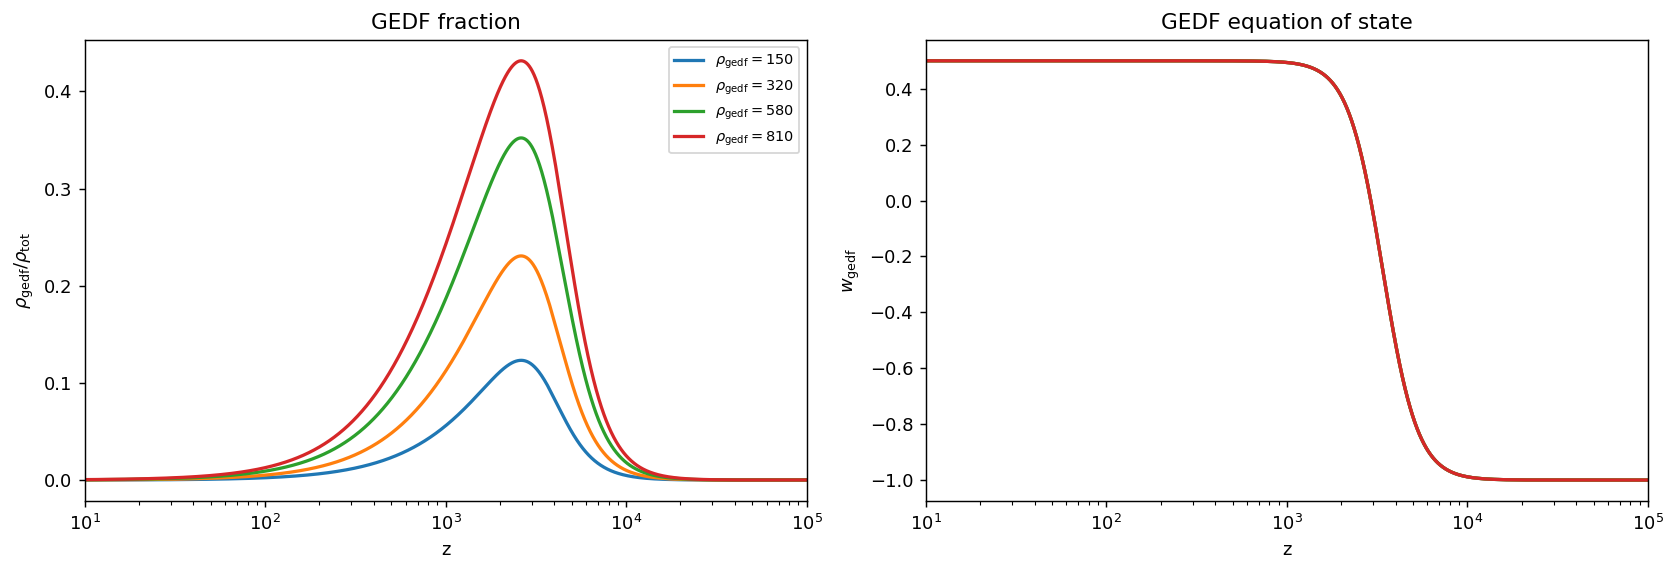

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for rho in RHO_VALUES:
    item = results[rho]
    label = rf'$\rho_{{\rm gedf}}={rho:g}$'
    axes[0].semilogx(item['z'], item['rho_fraction'], lw=1.8, label=label)
    axes[1].semilogx(item['z'], item['w_gedf'], lw=1.8, label=label)

axes[0].set_xlim(1e1, 1e5)
axes[0].set_xlabel('z')
axes[0].set_ylabel(r'$\rho_{\rm gedf}/\rho_{\rm tot}$')
axes[0].set_title('GEDF fraction')

axes[1].set_xlim(1e1, 1e5)
axes[1].set_xlabel('z')
axes[1].set_ylabel(r'$w_{\rm gedf}$')
axes[1].set_title('GEDF equation of state')

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


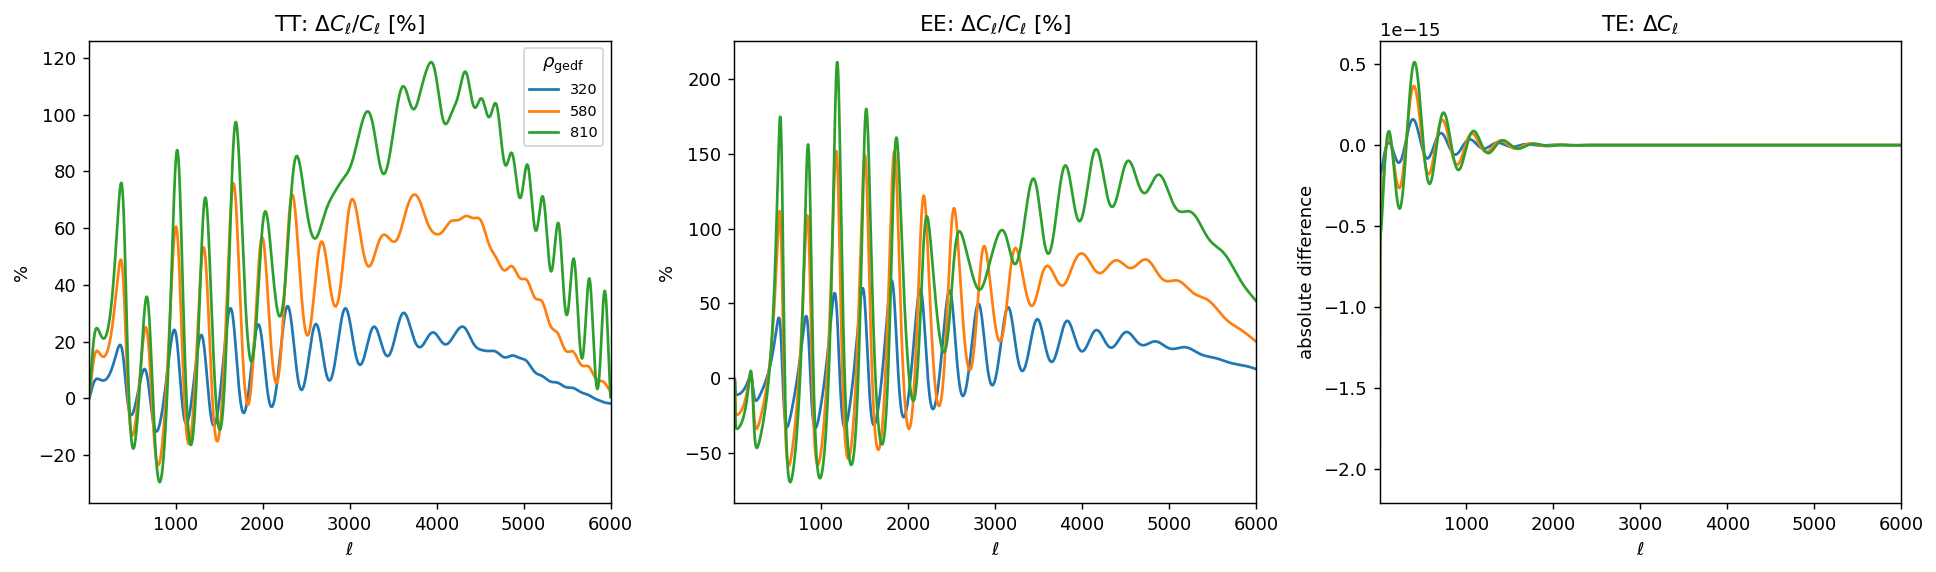

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)

for rho in RHO_VALUES[1:]:
    item = results[rho]
    dtt = (item['tt'] / reference['tt'] - 1.0) * 100.0
    dee = (item['ee'] / reference['ee'] - 1.0) * 100.0
    dte = item['te'] - reference['te']

    axes[0].plot(ell, dtt, lw=1.5, label=f'{rho:g}')
    axes[1].plot(ell, dee, lw=1.5, label=f'{rho:g}')
    axes[2].plot(ell, dte, lw=1.5, label=f'{rho:g}')

axes[0].set_title(r'TT: $\Delta C_\ell / C_\ell$ [%]')
axes[1].set_title(r'EE: $\Delta C_\ell / C_\ell$ [%]')
axes[2].set_title(r'TE: $\Delta C_\ell$')

for ax in axes:
    ax.set_xlim(2, L_MAX)
    ax.set_xlabel(r'$\ell$')

axes[0].set_ylabel('%')
axes[1].set_ylabel('%')
axes[2].set_ylabel('absolute difference')
axes[0].legend(title=r'$\rho_{\rm gedf}$', fontsize=8)

plt.tight_layout()
plt.show()


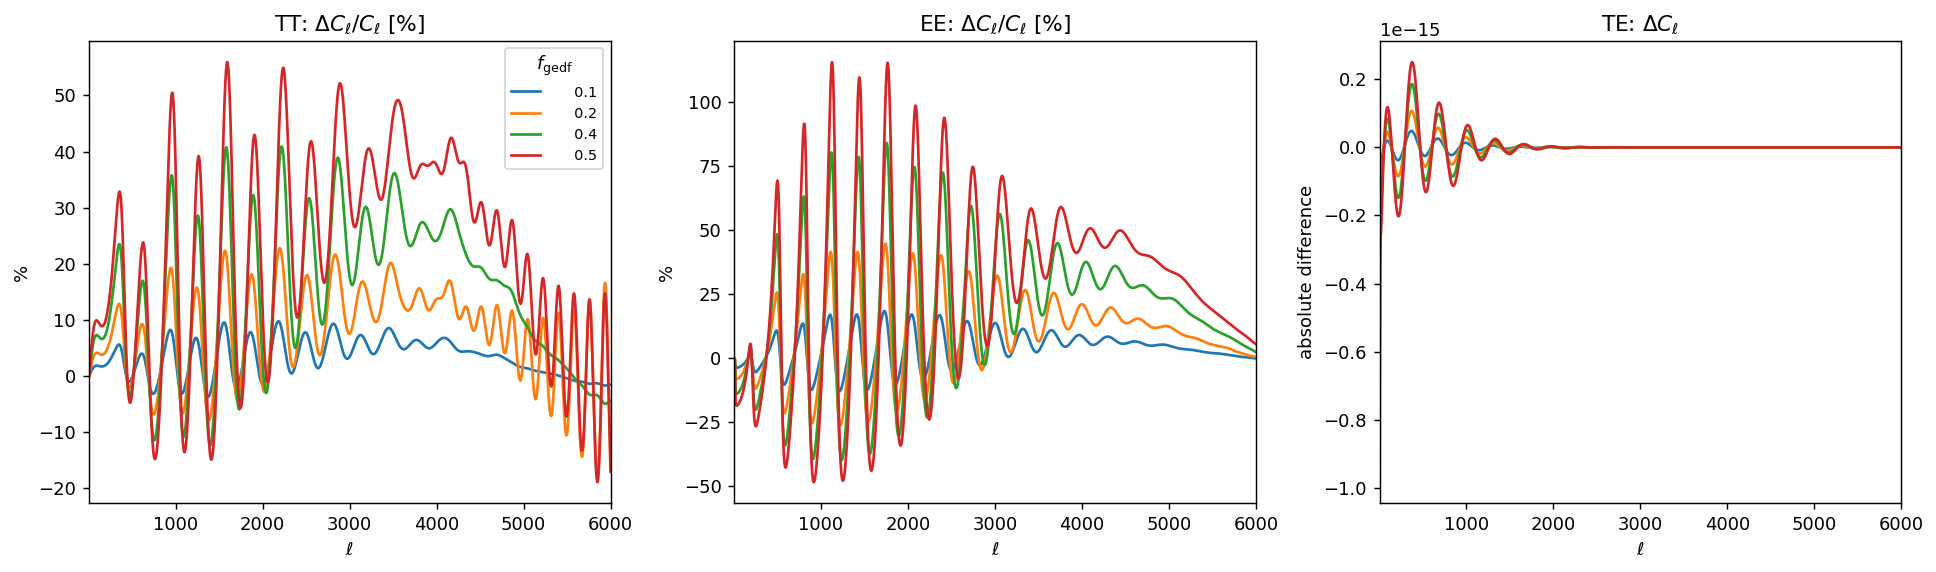

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)

for rho in RHO_VALUES[1:]:
    item = results[rho]
    dtt = (item['tt'] / ref_2['tt'] - 1.0) * 100.0
    dee = (item['ee'] / ref_2['ee'] - 1.0) * 100.0
    dte = item['te'] - ref_2['te']

    axes[0].plot(ell, dtt, lw=1.5, label=f'{item['f_gedf']:8.1f}')
    axes[1].plot(ell, dee, lw=1.5, label=f'{item['f_gedf']:8.1f}')
    axes[2].plot(ell, dte, lw=1.5, label=f'{item['f_gedf']:8.1f}')

axes[0].set_title(r'TT: $\Delta C_\ell / C_\ell$ [%]')
axes[1].set_title(r'EE: $\Delta C_\ell / C_\ell$ [%]')
axes[2].set_title(r'TE: $\Delta C_\ell$')

for ax in axes:
    ax.set_xlim(2, L_MAX)
    ax.set_xlabel(r'$\ell$')

axes[0].set_ylabel('%')
axes[1].set_ylabel('%')
axes[2].set_ylabel('absolute difference')
axes[0].legend(title=r'$f_{\rm gedf}$', fontsize=8)

plt.tight_layout()
plt.show()

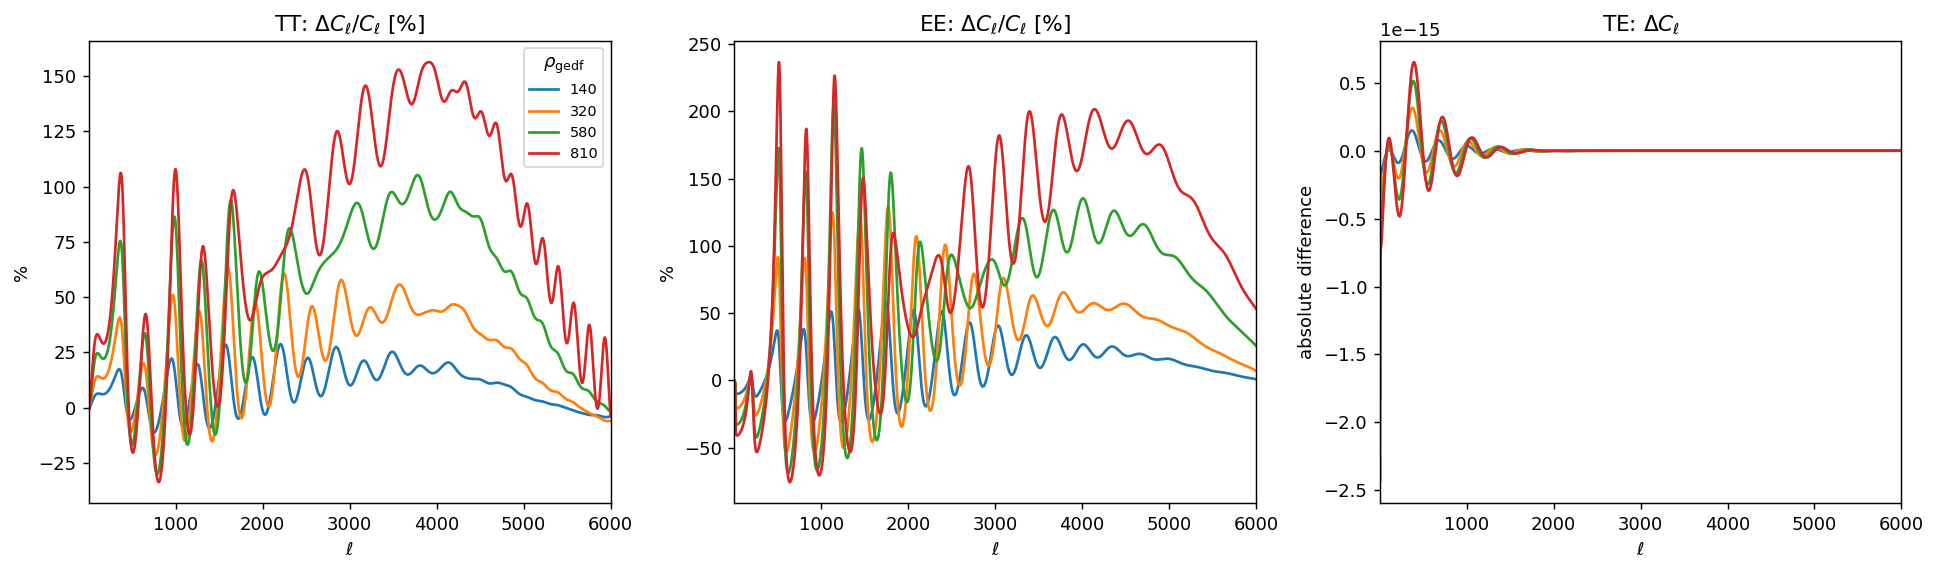

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)

for rho in RHO_VALUES[1:]:
    item = results[rho]
    dtt = (item['tt'] / ref_2['tt'] - 1.0) * 100.0
    dee = (item['ee'] / ref_2['ee'] - 1.0) * 100.0
    dte = item['te'] - ref_2['te']

    axes[0].plot(ell, dtt, lw=1.5, label=f'{rho:g}')
    axes[1].plot(ell, dee, lw=1.5, label=f'{rho:g}')
    axes[2].plot(ell, dte, lw=1.5, label=f'{rho:g}')

axes[0].set_title(r'TT: $\Delta C_\ell / C_\ell$ [%]')
axes[1].set_title(r'EE: $\Delta C_\ell / C_\ell$ [%]')
axes[2].set_title(r'TE: $\Delta C_\ell$')

for ax in axes:
    ax.set_xlim(2, L_MAX)
    ax.set_xlabel(r'$\ell$')

axes[0].set_ylabel('%')
axes[1].set_ylabel('%')
axes[2].set_ylabel('absolute difference')
axes[0].legend(title=r'$\rho_{\rm gedf}$', fontsize=8)

plt.tight_layout()
plt.show()

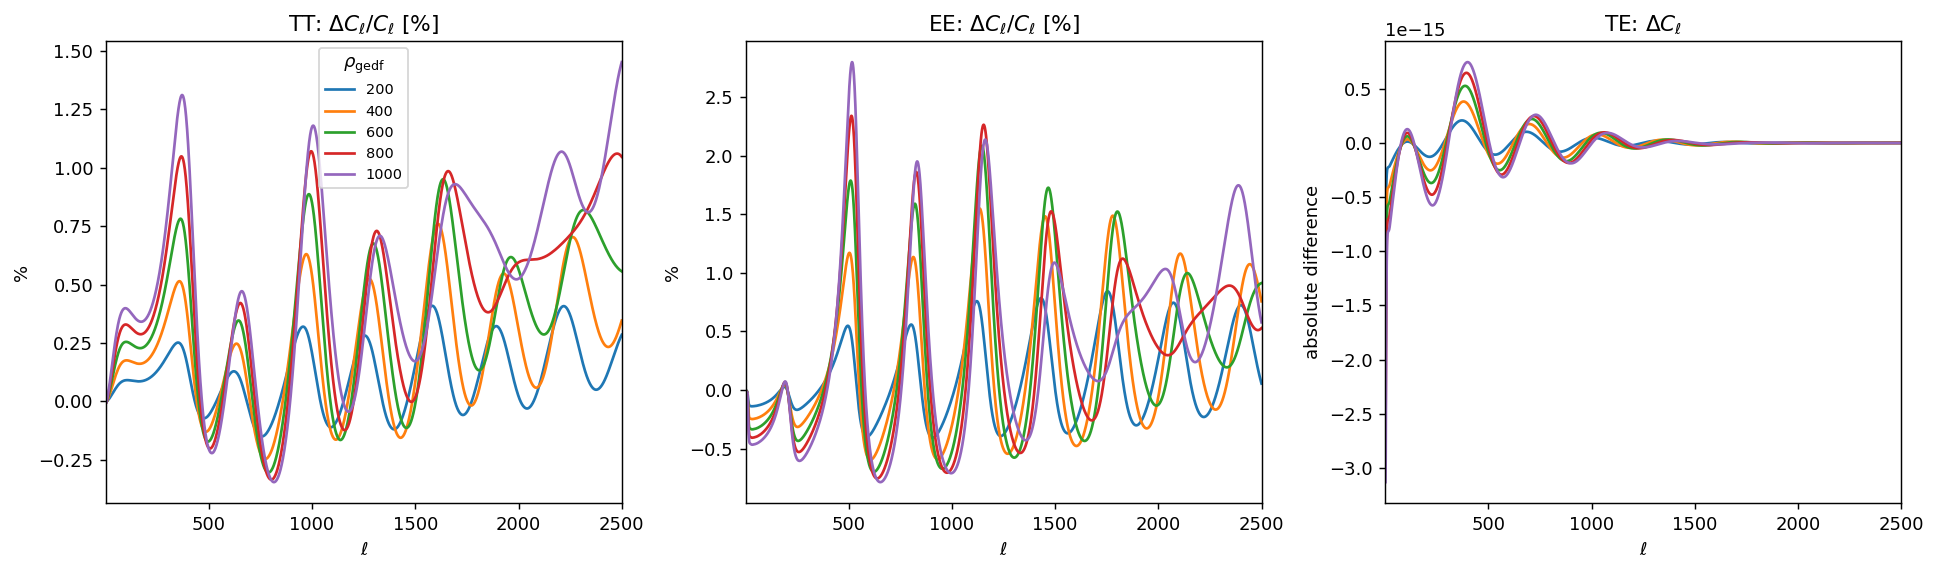

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)

for rho in RHO_VALUES[1:]:
    item = results[rho]
    dtt = (item['tt'] - reference['tt']) / reference['tt']
    dee = (item['ee'] - reference['ee']) / reference['ee'] 
    dte = item['te'] - reference['te']

    axes[0].plot(ell, dtt, lw=1.5, label=f'{rho:g}')
    axes[1].plot(ell, dee, lw=1.5, label=f'{rho:g}')
    axes[2].plot(ell, dte, lw=1.5, label=f'{rho:g}')

axes[0].set_title(r'TT: $\Delta C_\ell / C_\ell$ [%]')
axes[1].set_title(r'EE: $\Delta C_\ell / C_\ell$ [%]')
axes[2].set_title(r'TE: $\Delta C_\ell$')

for ax in axes:
    ax.set_xlim(2, L_MAX)
    ax.set_xlabel(r'$\ell$')

axes[0].set_ylabel('%')
axes[1].set_ylabel('%')
axes[2].set_ylabel('absolute difference')
axes[0].legend(title=r'$\rho_{\rm gedf}$', fontsize=8)

plt.tight_layout()
plt.show()


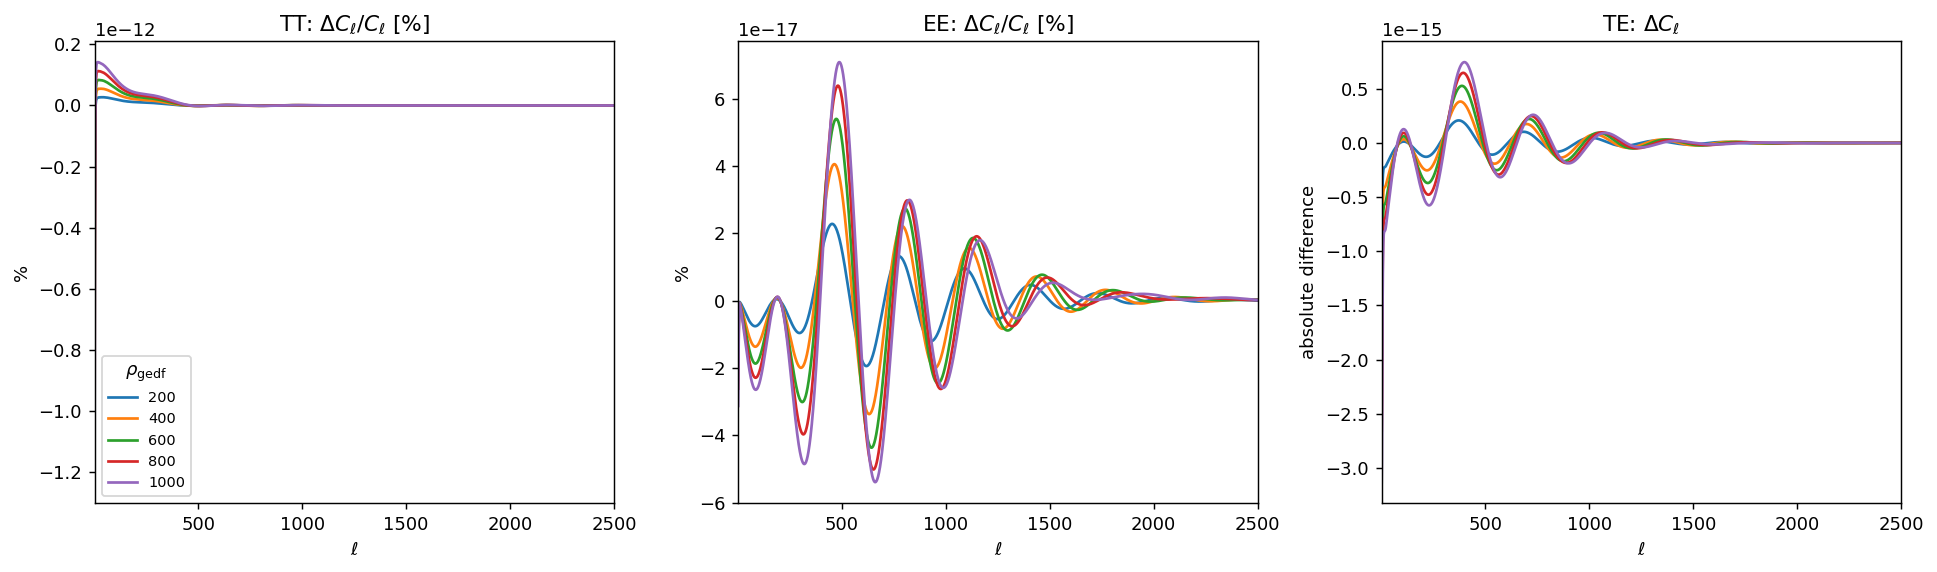

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)

for rho in RHO_VALUES[1:]:
    item = results[rho]
    dtt = item['tt'] - reference['tt']
    dee = item['ee'] - reference['ee']
    dte = item['te'] - reference['te']

    axes[0].plot(ell, dtt, lw=1.5, label=f'{rho:g}')
    axes[1].plot(ell, dee, lw=1.5, label=f'{rho:g}')
    axes[2].plot(ell, dte, lw=1.5, label=f'{rho:g}')

axes[0].set_title(r'TT: $\Delta C_\ell / C_\ell$ [%]')
axes[1].set_title(r'EE: $\Delta C_\ell / C_\ell$ [%]')
axes[2].set_title(r'TE: $\Delta C_\ell$')

for ax in axes:
    ax.set_xlim(2, L_MAX)
    ax.set_xlabel(r'$\ell$')

axes[0].set_ylabel('%')
axes[1].set_ylabel('%')
axes[2].set_ylabel('absolute difference')
axes[0].legend(title=r'$\rho_{\rm gedf}$', fontsize=8)

plt.tight_layout()
plt.show()